# 03 — Overlap Analysis & Segmentation Refinement

Inspects the two stages that sit between Detection and Cropping:

1. **`OverlapResolver`** — purely geometric. Flags detection pairs/groups with suspicious spatial overlap (IoU or directional containment). Never mutates or removes detections — it only decides *whether* refinement should run.
2. **`Refiner`** — dispatches to a segmentation backend (`sam2` / `mock_refiner` / `none`) for the flagged detections only, then validates each result against `refinement.output.*` sanity bounds (coverage, expansion, positional IoU) before it's allowed to replace the original bbox.

Covered in this notebook:

1. Setup and helpers
2. Find a densely-packed image and run `Detector`
3. Run `OverlapResolver` and inspect flagged pairs/groups
4. Visualize overlap groups on the image
5. Sensitivity of the trigger thresholds (`iou_threshold`, `overlap_ratio_threshold`)
6. Run `Refiner` (SAM2) on the flagged detections
7. Before/after comparison: original bbox vs refined bbox, including rejected (fallback) refinements
8. Aggregate refinement statistics across a small batch

> Note: the `sam2` backend requires `weights/refinement/sam2/sam2.1_hiera_small.pt` and, ideally, a CUDA GPU. If unavailable, switch `refinement.backend` to `"mock_refiner"` or `"none"` in the cells below.


## 1. Environment setup

In [1]:
import sys,os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Project root: {PROJECT_ROOT}")
assert (PROJECT_ROOT / "configs" / "config.yaml").is_file()

Project root: g:\VsCode\Python\DACN\stocktaking_ai_mini


In [2]:
import random

import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.core.config import load_config
from src.detection.detector import Detector
from src.pipeline.overlap import OverlapResolver, find_suspicious_pairs
from src.segmentation.refiner import Refiner
from src.models.models import ImageData

pd.set_option("display.max_colwidth", 80)
%matplotlib inline

In [3]:
config = load_config()

print(f"Refinement enabled:            {config.refinement.enabled}")
print(f"Refinement backend:            {config.refinement.backend}")
print(f"Trigger iou_threshold:         {config.refinement.trigger.iou_threshold}")
print(f"Trigger overlap_ratio_thresh:  {config.refinement.trigger.overlap_ratio_threshold}")
print(f"Trigger min_overlapping_pairs: {config.refinement.trigger.min_overlapping_pairs}")
print(f"Output min_mask_coverage:      {config.refinement.output.min_mask_coverage_ratio}")
print(f"Output max_bbox_expansion:     {config.refinement.output.max_bbox_expansion_ratio}")
print(f"Output min_refinement_iou:     {config.refinement.output.min_refinement_iou}")

Refinement enabled:            True
Refinement backend:            sam2
Trigger iou_threshold:         0.05
Trigger overlap_ratio_thresh:  0.2
Trigger min_overlapping_pairs: 1
Output min_mask_coverage:      0.55
Output max_bbox_expansion:     1.5
Output min_refinement_iou:     0.5


In [4]:
def load_image_data(image_path: Path) -> ImageData:
    """Loads an image file from disk into an ImageData DTO (BGR, HxWx3)."""
    image_array = cv2.imread(str(image_path))
    if image_array is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    height, width = image_array.shape[:2]
    return ImageData(
        image_id=image_path.stem,
        source_path=str(image_path),
        image_array=image_array,
        width=width,
        height=height,
    )


def show_image_bgr(ax, image_array_bgr: np.ndarray, title: str = ""):
    ax.imshow(cv2.cvtColor(image_array_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis("off")


def draw_boxes(ax, boxes, color="lime", labels=None):
    """boxes: list of BoundingBox. labels: optional list of strings, same length."""
    for i, box in enumerate(boxes):
        rect = patches.Rectangle(
            (box.x1, box.y1), box.width, box.height,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect)
        if labels is not None:
            ax.text(box.x1, max(0, box.y1 - 5), labels[i], color=color, fontsize=8, weight="bold")


GROUP_COLORS = ["red", "orange", "yellow", "magenta", "cyan", "lime", "blue"]

## 2. Find a densely-packed sample image

Overlap groups only appear on shelves with multiple, closely-packed products, so we scan a batch of images and pick the one with the most detections.

In [5]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

benchmark_images_dir = config.resolve_path(config.paths.benchmark_images_dir)
query_dir = config.resolve_path(config.paths.query_dir)
candidate_dir = benchmark_images_dir if benchmark_images_dir.exists() and any(
    benchmark_images_dir.iterdir()
) else query_dir

available_images = sorted([f for f in candidate_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS])
print(f"Using image source: {candidate_dir} ({len(available_images)} images)")
assert available_images, f"No images found in {candidate_dir}"

detector = Detector(config)
overlap_resolver = OverlapResolver(config)

SCAN_SIZE = min(15, len(available_images))
scan_paths = random.sample(available_images, k=SCAN_SIZE)

scan_rows = []
best_path, best_image_data, best_detection_result, best_count = None, None, None, -1

for path in scan_paths:
    img = load_image_data(path)
    result = detector.detect(img)
    scan_rows.append({"image": path.name, "num_detections": len(result.detections)})
    if len(result.detections) > best_count:
        best_path, best_image_data, best_detection_result, best_count = path, img, result, len(result.detections)

scan_df = pd.DataFrame(scan_rows).sort_values("num_detections", ascending=False).reset_index(drop=True)
display(scan_df)
print(f"Selected densest image: {best_path.name} ({best_count} detections)")

Using image source: G:\VsCode\Python\DACN\stocktaking_ai_mini\data\benchmark\images (31 images)


g:\VsCode\Python\DACN\stocktaking_ai_mini\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-03 18:06:57 | INFO     | src.detection.backends.rf_detr | Loading RF-DETR model class='RFDETRBase' kwargs={'pretrain_weights': 'weights/detector/checkpoint_best_ema.pth'}


g:\VsCode\Python\DACN\stocktaking_ai_mini\src\detection\backends\rf_detr.py:85: FutureWarning: The `RFDETRBase` was deprecated since v1.7.0. It will be removed in v2.0.0.
  logger.info("Loading RF-DETR model class='%s' kwargs=%s", model_cls.__name__, model_kwargs)
[2026-09-03 18:06:58] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.
[2026-09-03 18:06:58] [WARNING] rf-detr - load_pretrain_weights: args.num_queries absent; inferred ckpt_num_queries=300 from tensor rows 3900 ÷ ckpt_group_detr=13.


2026-09-03 18:06:58 | INFO     | src.detection.backends.rf_detr | Optimizing RF-DETR for inference (dtype=float32 compile=False batch_size=1)
2026-09-03 18:06:58 | INFO     | src.detection.backends.rf_detr | RfDetrBackend initialized (variant='base' weights_path='weights/detector/checkpoint_best_ema.pth')
2026-09-03 18:06:58 | INFO     | src.detection.detector | Detector initialized with backend='rf_detr'
2026-09-03 18:06:58 | INFO     | src.pipeline.overlap | OverlapResolver initialized (enabled=True iou_threshold=0.050 overlap_ratio_threshold=0.200 min_overlapping_pairs=1 require_multiple_detections=True)
2026-09-03 18:07:00 | INFO     | src.detection.detector | Detector found 13 region(s) in image_id='IMG_0587_jpg.rf.LxxOk1MVhf03y54rDLcP' (1512.29 ms)
2026-09-03 18:07:00 | INFO     | src.detection.detector | Detector found 9 region(s) in image_id='7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9' (179.23 ms)
2026-09-03 18:07:00 | INFO     | src.detection.detector | Detector found 14 region(s) in image

,image,num_detections
0,9_jpg.rf.OPYepIWn6WJg2jb9RLlK.jpg,16
1,IMG_0579_jpg.rf.yowq0fDPnqwaYtLv6B8z.jpg,14
2,IMG_0575_jpg.rf.XUIF5UvBEjaGhidFhPW3.jpg,14
3,IMG_0587_jpg.rf.LxxOk1MVhf03y54rDLcP.jpg,13
4,IMG_0578_jpg.rf.oPsBmrQrOFfXvlzydeX4.jpg,13
5,4_jpg.rf.S4wtp8A57PrQcTLrJiUx.jpg,13
6,6_jpg.rf.fsTWp5Ex5KXGN11ElAye.jpg,12
7,1_jpg.rf.3Fmjpfai8022RF7eJDn5.jpg,10
8,3_jpg.rf.ZbJrojyWq6VoaQRpgI1u.jpg,10
9,7_jpg.rf.oQ4WxRz7iWKzjAEX7gd9.jpg,9


Selected densest image: 9_jpg.rf.OPYepIWn6WJg2jb9RLlK.jpg (16 detections)


## 3. Run OverlapResolver

In [6]:
overlap_result = overlap_resolver.resolve(best_detection_result)

print(f"needs_refinement:            {overlap_result.needs_refinement}")
print(f"Suspicious pairs:            {len(overlap_result.pairs)}")
print(f"Overlap groups:              {overlap_result.group_count}")
print(f"Detections involved:         {overlap_result.overlapping_detection_count} / {len(best_detection_result.detections)}")

2026-09-03 18:07:06 | INFO     | src.pipeline.overlap | OverlapResolver flagged 50 suspicious pair(s) forming 1 group(s) for image_id='9_jpg.rf.OPYepIWn6WJg2jb9RLlK' (0.46 ms)
needs_refinement:            True
Suspicious pairs:            50
Overlap groups:              1
Detections involved:         16 / 16


In [7]:
pairs_df = pd.DataFrame([
    {
        "a": p.detection_index_a,
        "b": p.detection_index_b,
        "iou": round(p.iou, 3),
        "ratio_a": round(p.intersection_ratio_a, 3),
        "ratio_b": round(p.intersection_ratio_b, 3),
        "containment": p.is_containment,
    }
    for p in overlap_result.pairs
])
pairs_df

,a,b,iou,ratio_a,ratio_b,containment
0,0,3,0.312,0.914,0.322,False
1,0,5,0.098,0.154,0.211,False
2,0,13,0.142,0.546,0.161,False
3,1,13,0.045,0.227,0.053,False
4,2,10,0.498,1.000,0.498,True
5,3,10,0.105,0.141,0.287,False
6,3,13,0.085,0.171,0.143,False
7,4,6,0.788,1.000,0.788,True
8,4,7,0.943,0.953,0.989,False
9,4,8,0.216,0.216,1.000,True


In [8]:
groups_df = pd.DataFrame([
    {"group_id": g.group_id, "size": g.size, "detection_indices": g.detection_indices, "num_pairs": len(g.pairs)}
    for g in overlap_result.groups
])
groups_df

,group_id,size,detection_indices,num_pairs
0,0,16,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]",50


## 4. Visualize overlap groups

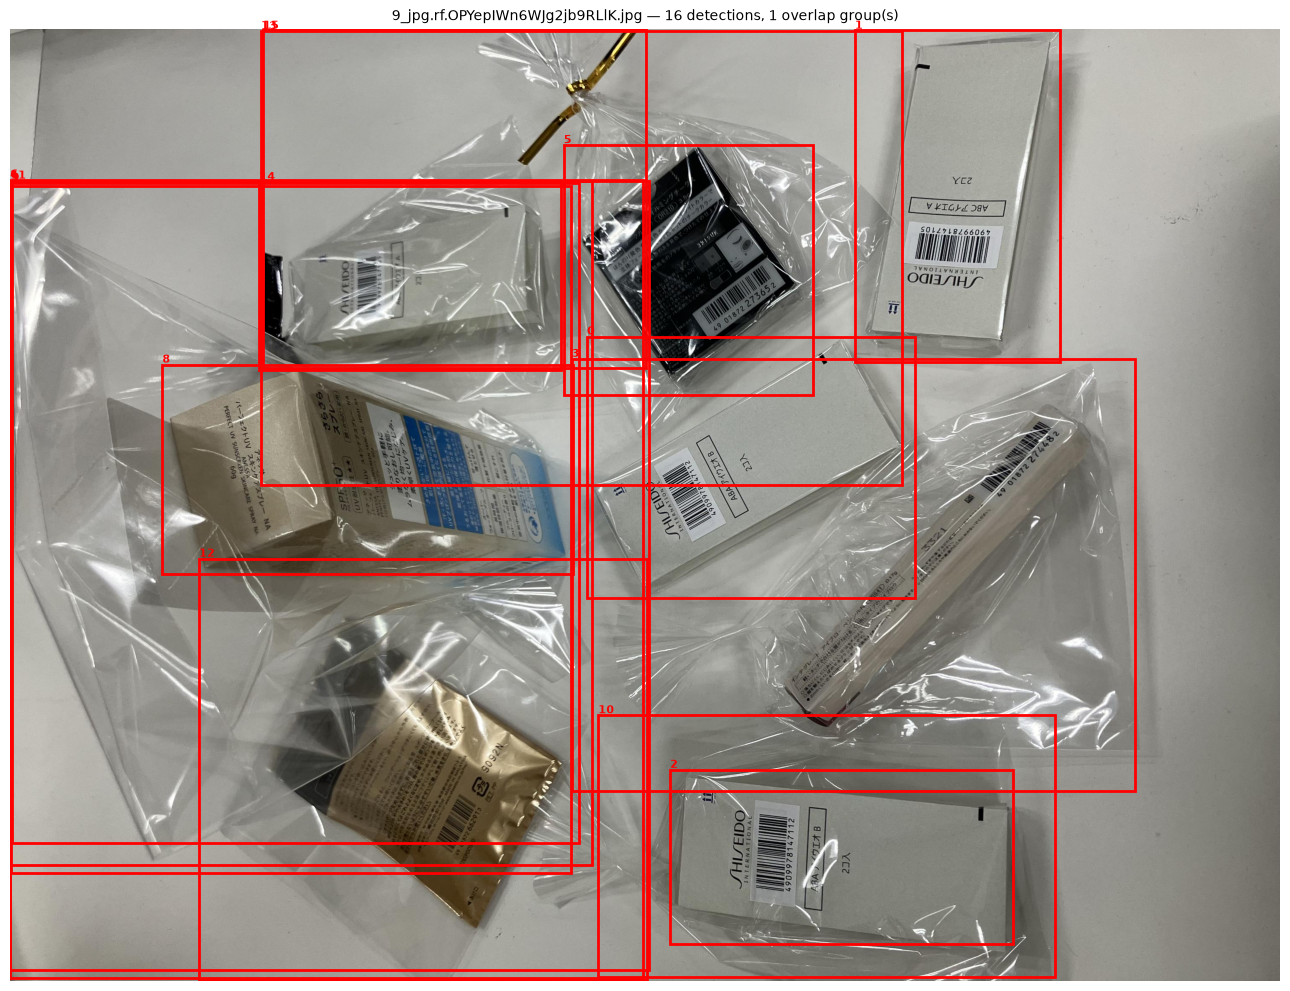

In [9]:
fig, ax = plt.subplots(figsize=(13, 13))
show_image_bgr(
    ax, best_image_data.image_array,
    title=f"{best_path.name} — {len(best_detection_result.detections)} detections, "
          f"{overlap_result.group_count} overlap group(s)",
)

grouped_indices = {idx for g in overlap_result.groups for idx in g.detection_indices}

# Detections NOT part of any overlap group: plain gray
non_group_boxes = [d.bbox for i, d in enumerate(best_detection_result.detections) if i not in grouped_indices]
draw_boxes(ax, non_group_boxes, color="gray")

# Each overlap group gets its own color
for group in overlap_result.groups:
    color = GROUP_COLORS[group.group_id % len(GROUP_COLORS)]
    boxes = [best_detection_result.detections[i].bbox for i in group.detection_indices]
    labels = [str(i) for i in group.detection_indices]
    draw_boxes(ax, boxes, color=color, labels=labels)

plt.tight_layout()
plt.show()

## 5. Trigger threshold sensitivity

`find_suspicious_pairs` is a pure function (no config/state) — the same one VAL's Overlap-stage evaluator uses — so we can sweep thresholds directly without rebuilding `OverlapResolver`.

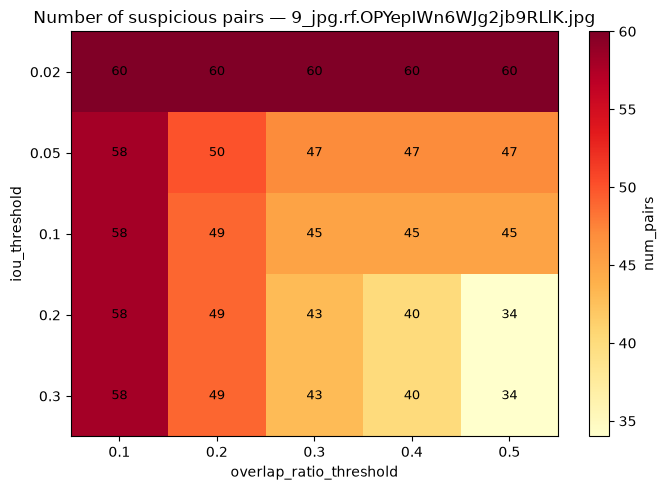

Configured operating point: iou_threshold=0.05, overlap_ratio_threshold=0.2


In [10]:
iou_thresholds = [0.02, 0.05, 0.10, 0.20, 0.30]
overlap_ratio_thresholds = [0.10, 0.20, 0.30, 0.40, 0.50]

sensitivity_rows = []
for iou_t in iou_thresholds:
    for ratio_t in overlap_ratio_thresholds:
        pairs = find_suspicious_pairs(best_detection_result.detections, iou_t, ratio_t)
        sensitivity_rows.append({"iou_threshold": iou_t, "overlap_ratio_threshold": ratio_t, "num_pairs": len(pairs)})

sensitivity_df = pd.DataFrame(sensitivity_rows)
pivot = sensitivity_df.pivot(index="iou_threshold", columns="overlap_ratio_threshold", values="num_pairs")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("overlap_ratio_threshold")
ax.set_ylabel("iou_threshold")
ax.set_title(f"Number of suspicious pairs — {best_path.name}")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, int(pivot.values[i, j]), ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="num_pairs")
plt.tight_layout()
plt.show()

configured_point = (config.refinement.trigger.iou_threshold, config.refinement.trigger.overlap_ratio_threshold)
print(f"Configured operating point: iou_threshold={configured_point[0]}, "
      f"overlap_ratio_threshold={configured_point[1]}")

## 6. Run Refiner (segmentation)

Only meaningful when `overlap_result.needs_refinement` is True — otherwise there is nothing to refine on this image.

In [11]:
if not overlap_result.needs_refinement:
    print("This image did not trigger refinement. Re-run cell 2 to sample a different image, "
          "or lower the thresholds in configs/config.yaml.")
else:
    try:
        refiner = Refiner(config)
        refinement_result = refiner.refine(best_image_data.image_array, best_detection_result, overlap_result)
        print(f"Backend:            {refinement_result.backend}")
        print(f"Triggered:          {refinement_result.triggered}")
        print(f"Refined boxes:      {len(refinement_result.refined_boxes)}")
    except Exception as exc:
        refinement_result = None
        print(f"Could not run backend '{config.refinement.backend}' "
              f"(likely missing weights/dependencies): {exc}")

2026-09-03 18:07:08 | INFO     | src.segmentation.backends.sam2 | SAM2 checkpoint found locally: 'weights\refinement\sam2\sam2.1_hiera_small.pt'
2026-09-03 18:07:08 | INFO     | src.segmentation.backends.sam2 | Loading SAM2 model_config='configs/sam2.1/sam2.1_hiera_s.yaml' checkpoint='weights\refinement\sam2\sam2.1_hiera_small.pt' device='cuda'
2026-09-03 18:07:11 | INFO     | src.segmentation.backends.sam2 | Sam2Backend initialized (model_type='sam2.1_hiera_small' device='cuda')
2026-09-03 18:07:11 | INFO     | src.segmentation.refiner | Refiner initialized with backend='sam2' enabled=True
2026-09-03 18:07:17 | INFO     | src.segmentation.refiner | Refiner processed 16 detection(s) for image_id='9_jpg.rf.OPYepIWn6WJg2jb9RLlK' (6542.41 ms)
Backend:            sam2
Triggered:          True
Refined boxes:      16


In [12]:
if overlap_result.needs_refinement and refinement_result is not None:
    refine_df = pd.DataFrame([
        {
            "detection_index": rb.detection_index,
            "mask_area_ratio": round(rb.mask_area_ratio, 3),
            "refinement_confidence": round(rb.refinement_confidence, 3),
            "used_fallback": rb.used_fallback,
            "backend": rb.backend,
        }
        for rb in refinement_result.refined_boxes
    ])
    display(refine_df)

    accepted = (~refine_df["used_fallback"]).sum() if not refine_df.empty else 0
    rejected = refine_df["used_fallback"].sum() if not refine_df.empty else 0
    print(f"Accepted refinements: {accepted}")
    print(f"Rejected (fallback):  {rejected}  — see Refiner._apply_output_policy for rejection criteria")

,detection_index,mask_area_ratio,refinement_confidence,used_fallback,backend
0,0,0.453,0.848,True,sam2
1,1,0.589,0.923,False,sam2
2,2,0.746,0.975,False,sam2
3,3,0.546,0.874,True,sam2
4,4,0.477,0.923,True,sam2
5,5,0.432,0.959,True,sam2
6,6,0.531,0.847,True,sam2
7,7,0.481,0.916,True,sam2
8,8,0.596,0.936,False,sam2
9,9,0.565,0.801,False,sam2


Accepted refinements: 6
Rejected (fallback):  10  — see Refiner._apply_output_policy for rejection criteria


## 7. Before/after comparison

Original detector bbox (gray, dashed) vs the refined bbox actually kept after `Refiner._apply_output_policy` validation (green = accepted refinement, red = rejected/fallback).

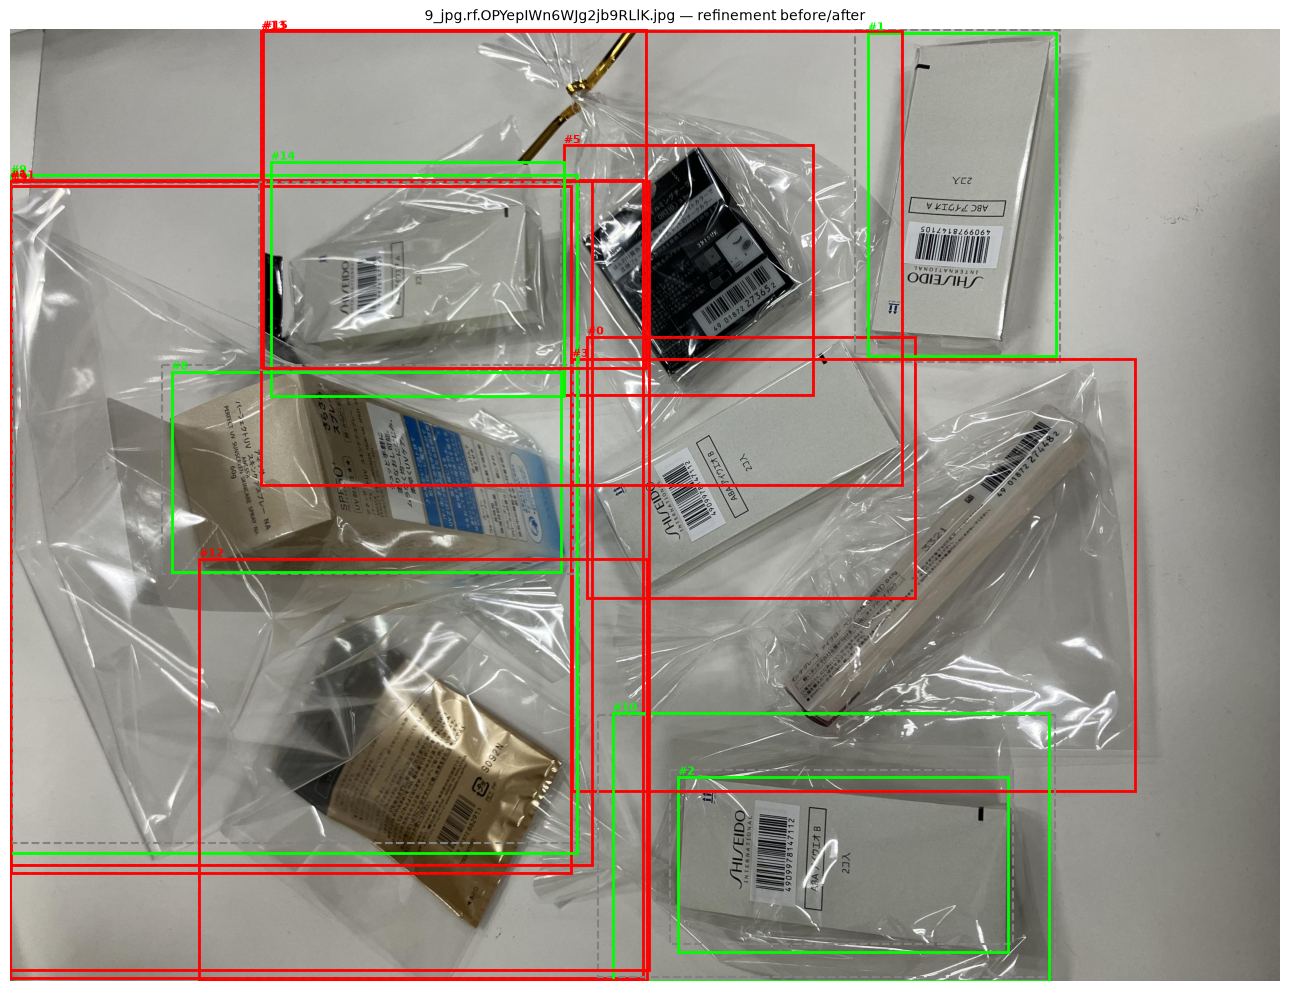

Gray dashed = original detector bbox · Green = accepted refinement · Red = rejected (fallback to original)


In [13]:
if overlap_result.needs_refinement and refinement_result is not None and refinement_result.refined_boxes:
    fig, ax = plt.subplots(figsize=(13, 13))
    show_image_bgr(ax, best_image_data.image_array, title=f"{best_path.name} — refinement before/after")

    for rb in refinement_result.refined_boxes:
        original_bbox = best_detection_result.detections[rb.detection_index].bbox
        rect_orig = patches.Rectangle(
            (original_bbox.x1, original_bbox.y1), original_bbox.width, original_bbox.height,
            linewidth=1.5, edgecolor="gray", linestyle="--", facecolor="none",
        )
        ax.add_patch(rect_orig)

        color = "red" if rb.used_fallback else "lime"
        rect_refined = patches.Rectangle(
            (rb.refined_bbox.x1, rb.refined_bbox.y1), rb.refined_bbox.width, rb.refined_bbox.height,
            linewidth=2, edgecolor=color, facecolor="none",
        )
        ax.add_patch(rect_refined)
        ax.text(rb.refined_bbox.x1, max(0, rb.refined_bbox.y1 - 5), f"#{rb.detection_index}",
                color=color, fontsize=8, weight="bold")

    plt.tight_layout()
    plt.show()
    print("Gray dashed = original detector bbox · Green = accepted refinement · Red = rejected (fallback to original)")
else:
    print("No refined boxes to visualize.")

## 8. Aggregate refinement statistics across a batch

In [14]:
BATCH_SIZE = min(10, len(available_images))
batch_paths = random.sample(available_images, k=BATCH_SIZE)

agg_rows = []
for path in batch_paths:
    img = load_image_data(path)
    det_result = detector.detect(img)
    ov_result = overlap_resolver.resolve(det_result)

    row = {
        "image": path.name,
        "num_detections": len(det_result.detections),
        "needs_refinement": ov_result.needs_refinement,
        "num_groups": ov_result.group_count,
        "num_overlapping_detections": ov_result.overlapping_detection_count,
    }

    if ov_result.needs_refinement:
        try:
            ref_result = refiner.refine(img.image_array, det_result, ov_result)
            row["num_refined"] = len(ref_result.refined_boxes)
            row["num_accepted"] = sum(1 for rb in ref_result.refined_boxes if not rb.used_fallback)
            row["num_fallback"] = sum(1 for rb in ref_result.refined_boxes if rb.used_fallback)
        except Exception:
            row["num_refined"] = row["num_accepted"] = row["num_fallback"] = None
    else:
        row["num_refined"] = row["num_accepted"] = row["num_fallback"] = 0

    agg_rows.append(row)

agg_df = pd.DataFrame(agg_rows)
display(agg_df)

trigger_rate = agg_df["needs_refinement"].mean()
print(f"Refinement trigger rate over {BATCH_SIZE} image(s): {trigger_rate:.1%}")
if agg_df["num_refined"].notna().any():
    total_refined = agg_df["num_refined"].sum()
    total_accepted = agg_df["num_accepted"].sum()
    total_fallback = agg_df["num_fallback"].sum()
    acceptance_rate = total_accepted / total_refined if total_refined else 0.0
    print(f"Total refined boxes:  {total_refined}")
    print(f"Accepted:             {total_accepted} ({acceptance_rate:.1%})")
    print(f"Rejected (fallback):  {total_fallback}")

2026-09-03 18:07:19 | INFO     | src.detection.detector | Detector found 16 region(s) in image_id='9_jpg.rf.OPYepIWn6WJg2jb9RLlK' (131.24 ms)
2026-09-03 18:07:19 | INFO     | src.pipeline.overlap | OverlapResolver flagged 50 suspicious pair(s) forming 1 group(s) for image_id='9_jpg.rf.OPYepIWn6WJg2jb9RLlK' (0.89 ms)
2026-09-03 18:07:23 | INFO     | src.segmentation.refiner | Refiner processed 16 detection(s) for image_id='9_jpg.rf.OPYepIWn6WJg2jb9RLlK' (4393.76 ms)
2026-09-03 18:07:24 | INFO     | src.detection.detector | Detector found 10 region(s) in image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (102.82 ms)
2026-09-03 18:07:24 | INFO     | src.pipeline.overlap | OverlapResolver flagged 2 suspicious pair(s) forming 2 group(s) for image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (0.15 ms)
2026-09-03 18:07:25 | INFO     | src.segmentation.refiner | Refiner processed 4 detection(s) for image_id='3_jpg.rf.ZbJrojyWq6VoaQRpgI1u' (1074.13 ms)
2026-09-03 18:07:25 | INFO     | src.detection.detector | Dete

,image,num_detections,needs_refinement,num_groups,num_overlapping_detections,num_refined,num_accepted,num_fallback
0,9_jpg.rf.OPYepIWn6WJg2jb9RLlK.jpg,16,True,1,16,16,6,10
1,3_jpg.rf.ZbJrojyWq6VoaQRpgI1u.jpg,10,True,2,4,4,2,2
2,IMG_0584_jpg.rf.wptS3bNs32eYYx2qz1RR.jpg,7,True,1,7,7,1,6
3,IMG_0578_jpg.rf.oPsBmrQrOFfXvlzydeX4.jpg,13,True,1,12,12,6,6
4,IMG_0581_jpg.rf.cOequ09kjV1NVU0Vosud.jpg,7,True,1,3,3,3,0
5,5_jpg.rf.MscUJmygpu0eYooK7BGq.jpg,9,True,2,7,7,6,1
6,1_jpg.rf.3Fmjpfai8022RF7eJDn5.jpg,10,True,2,5,5,1,4
7,IMG_0571_jpg.rf.wDQI80G5OWb6z140D94u.jpg,7,True,1,4,4,2,2
8,IMG_0569_jpg.rf.cDK0vyv3sXtlEyBdiQPz.jpg,7,True,1,6,6,2,4
9,IMG_0585_jpg.rf.HCnXlWzg3J5bck8QWMUr.jpg,12,True,2,11,11,7,4


Refinement trigger rate over 10 image(s): 100.0%
Total refined boxes:  75
Accepted:             36 (48.0%)
Rejected (fallback):  39


## 9. Summary

In [15]:
summary = {
    "Sample image": best_path.name,
    "Detections": len(best_detection_result.detections),
    "Suspicious pairs": len(overlap_result.pairs),
    "Overlap groups": overlap_result.group_count,
    "Refinement backend": config.refinement.backend,
    "Batch refinement trigger rate": f"{trigger_rate:.1%}" if 'trigger_rate' in dir() else "n/a",
}
pd.DataFrame([summary]).T.rename(columns={0: "Value"})

,Value
Sample image,9_jpg.rf.OPYepIWn6WJg2jb9RLlK.jpg
Detections,16
Suspicious pairs,50
Overlap groups,1
Refinement backend,sam2
Batch refinement trigger rate,100.0%


---
**Quick observations (fill in after running on real data):**

- At the configured operating point (`iou_threshold`, `overlap_ratio_threshold`), does the number of flagged pairs look reasonable for typical shelf density, or is it over/under-triggering?
- What fraction of SAM2 refinements get rejected by `Refiner._apply_output_policy`, and for which reason (coverage / expansion / positional IoU)? This is a good place to look if refined boxes look worse than raw detections.
- Does refinement noticeably change the *raw* crop content that OCR/Color/Barcode plugins will see later?

**Next notebook:** `04_retrieval_analysis.ipynb` — SigLIP2 embeddings, FAISS gallery search, and Top-K retrieval quality on the crops produced from these (possibly refined) boxes.
